In [4]:
import numpy as np 
import pandas as pd

In [8]:
df = pd.read_csv("amazon_products_clean.csv")

In [10]:
df

,asin,amazon_category,category_id,stars,reviews,price,listprice,isbestseller,boughtinlastmonth
0,B014TMV5YE,Suitcases,104,4.5,0,139.99,0.00,False,2000
1,B07GDLCQXV,Suitcases,104,4.5,0,169.99,209.99,False,1000
2,B07XSCCZYG,Suitcases,104,4.6,0,365.49,429.99,False,300
3,B08MVFKGJM,Suitcases,104,4.6,0,291.59,354.37,False,400
4,B01DJLKZBA,Suitcases,104,4.5,0,174.99,309.99,False,400
...,...,...,...,...,...,...,...,...,...
1426332,B00R3LIKCO,Men's Accessories,112,4.2,0,14.95,0.00,False,0
1426333,B098BQ7ZQ3,Men's Accessories,112,4.4,0,33.99,0.00,False,0
1426334,B07X1MVNT1,Men's Accessories,112,3.6,0,8.54,0.00,False,0
1426335,B08XLBG8V9,Men's Accessories,112,4.5,0,54.36,57.39,False,0


In [13]:
# FEATURE ENGINEERING 
# Creating column discount price
df["discount_amount"] = df["listprice"] - df["price"]

In [15]:
df

,asin,amazon_category,category_id,stars,reviews,price,listprice,isbestseller,boughtinlastmonth,discount_amount
0,B014TMV5YE,Suitcases,104,4.5,0,139.99,0.00,False,2000,-139.99
1,B07GDLCQXV,Suitcases,104,4.5,0,169.99,209.99,False,1000,40.00
2,B07XSCCZYG,Suitcases,104,4.6,0,365.49,429.99,False,300,64.50
3,B08MVFKGJM,Suitcases,104,4.6,0,291.59,354.37,False,400,62.78
4,B01DJLKZBA,Suitcases,104,4.5,0,174.99,309.99,False,400,135.00
...,...,...,...,...,...,...,...,...,...,...
1426332,B00R3LIKCO,Men's Accessories,112,4.2,0,14.95,0.00,False,0,-14.95
1426333,B098BQ7ZQ3,Men's Accessories,112,4.4,0,33.99,0.00,False,0,-33.99
1426334,B07X1MVNT1,Men's Accessories,112,3.6,0,8.54,0.00,False,0,-8.54
1426335,B08XLBG8V9,Men's Accessories,112,4.5,0,54.36,57.39,False,0,3.03


In [18]:
# New Column Discount %
df["discount_percentage"] = (
    (df["listprice"] - df["price"])
    / df["listprice"]
) * 100

df["discount_percentage"] = df["discount_percentage"].round(2)

In [20]:
df

,asin,amazon_category,category_id,stars,reviews,price,listprice,isbestseller,boughtinlastmonth,discount_amount,discount_percentage
0,B014TMV5YE,Suitcases,104,4.5,0,139.99,0.00,False,2000,-139.99,-inf
1,B07GDLCQXV,Suitcases,104,4.5,0,169.99,209.99,False,1000,40.00,19.05
2,B07XSCCZYG,Suitcases,104,4.6,0,365.49,429.99,False,300,64.50,15.00
3,B08MVFKGJM,Suitcases,104,4.6,0,291.59,354.37,False,400,62.78,17.72
4,B01DJLKZBA,Suitcases,104,4.5,0,174.99,309.99,False,400,135.00,43.55
...,...,...,...,...,...,...,...,...,...,...,...
1426332,B00R3LIKCO,Men's Accessories,112,4.2,0,14.95,0.00,False,0,-14.95,-inf
1426333,B098BQ7ZQ3,Men's Accessories,112,4.4,0,33.99,0.00,False,0,-33.99,-inf
1426334,B07X1MVNT1,Men's Accessories,112,3.6,0,8.54,0.00,False,0,-8.54,-inf
1426335,B08XLBG8V9,Men's Accessories,112,4.5,0,54.36,57.39,False,0,3.03,5.28


In [26]:
# Price Band Column
def price_band(price):

    if price < 400:
        return "Budget"

    elif price < 1500:
        return "Mid-Range"

    elif price < 3000:
        return "Premium"

    else:
        return "Luxury"

df["price_band"] = df["price"].apply(price_band)

In [28]:
df

,asin,amazon_category,category_id,stars,reviews,price,listprice,isbestseller,boughtinlastmonth,discount_amount,discount_percentage,price_band
0,B014TMV5YE,Suitcases,104,4.5,0,139.99,0.00,False,2000,-139.99,-inf,Budget
1,B07GDLCQXV,Suitcases,104,4.5,0,169.99,209.99,False,1000,40.00,19.05,Budget
2,B07XSCCZYG,Suitcases,104,4.6,0,365.49,429.99,False,300,64.50,15.00,Budget
3,B08MVFKGJM,Suitcases,104,4.6,0,291.59,354.37,False,400,62.78,17.72,Budget
4,B01DJLKZBA,Suitcases,104,4.5,0,174.99,309.99,False,400,135.00,43.55,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...
1426332,B00R3LIKCO,Men's Accessories,112,4.2,0,14.95,0.00,False,0,-14.95,-inf,Budget
1426333,B098BQ7ZQ3,Men's Accessories,112,4.4,0,33.99,0.00,False,0,-33.99,-inf,Budget
1426334,B07X1MVNT1,Men's Accessories,112,3.6,0,8.54,0.00,False,0,-8.54,-inf,Budget
1426335,B08XLBG8V9,Men's Accessories,112,4.5,0,54.36,57.39,False,0,3.03,5.28,Budget


In [30]:
# New Column Rating Category 
def rating_category(stars):

    if stars >= 4.5:
        return "Excellent"

    elif stars >= 4:
        return "Very Good"

    elif stars >= 3:
        return "Good"

    else:
        return "Poor"

df["rating_category"] = df["stars"].apply(rating_category)

In [32]:
df

,asin,amazon_category,category_id,stars,reviews,price,listprice,isbestseller,boughtinlastmonth,discount_amount,discount_percentage,price_band,rating_category
0,B014TMV5YE,Suitcases,104,4.5,0,139.99,0.00,False,2000,-139.99,-inf,Budget,Excellent
1,B07GDLCQXV,Suitcases,104,4.5,0,169.99,209.99,False,1000,40.00,19.05,Budget,Excellent
2,B07XSCCZYG,Suitcases,104,4.6,0,365.49,429.99,False,300,64.50,15.00,Budget,Excellent
3,B08MVFKGJM,Suitcases,104,4.6,0,291.59,354.37,False,400,62.78,17.72,Budget,Excellent
4,B01DJLKZBA,Suitcases,104,4.5,0,174.99,309.99,False,400,135.00,43.55,Budget,Excellent
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1426332,B00R3LIKCO,Men's Accessories,112,4.2,0,14.95,0.00,False,0,-14.95,-inf,Budget,Very Good
1426333,B098BQ7ZQ3,Men's Accessories,112,4.4,0,33.99,0.00,False,0,-33.99,-inf,Budget,Very Good
1426334,B07X1MVNT1,Men's Accessories,112,3.6,0,8.54,0.00,False,0,-8.54,-inf,Budget,Good
1426335,B08XLBG8V9,Men's Accessories,112,4.5,0,54.36,57.39,False,0,3.03,5.28,Budget,Excellent


In [34]:
# Demand Column accn to purchasing volume
def demand_category(bought):

    if bought < 100:
        return "Low"

    elif bought < 500:
        return "Medium"

    elif bought < 2000:
        return "High"

    else:
        return "Very High"

df["demand_category"] = df["boughtinlastmonth"].apply(demand_category)

In [36]:
# Bestseller Label column
df["bestseller_label"] = np.where(
    df["isbestseller"] == True,
    "Bestseller",
    "Non-Bestseller"
)

In [38]:
# Value Index column
df["value_index"] = (
    df["stars"] * 100
) / df["price"]

df["value_index"] = df["value_index"].round(4)

In [40]:
# Discount category column
def discount_category(discount):

    if discount <= 40:
        return "Low"

    elif discount <= 90:
        return "Medium"

    elif discount <= 110:
        return "High"

    else:
        return "Heavy Discount"

df["discount_category"] = df["discount_percentage"].apply(discount_category)

In [42]:
# Price Premium Column
df["price_premium"] = np.where(
    df["price"] > df["price"].median(),
    "Premium",
    "Standard"
)

In [44]:
# Discount flag 
df["discount_flag"] = np.where(
    df["discount_percentage"] > 0,
    "Discounted",
    "No Discount"
)

In [48]:
df

,asin,amazon_category,category_id,stars,reviews,price,listprice,isbestseller,boughtinlastmonth,discount_amount,discount_percentage,price_band,rating_category,demand_category,bestseller_label,value_index,discount_category,price_premium,discount_flag
0,B014TMV5YE,Suitcases,104,4.5,0,139.99,0.00,False,2000,-139.99,-inf,Budget,Excellent,Very High,Non-Bestseller,3.2145,Low,Premium,No Discount
1,B07GDLCQXV,Suitcases,104,4.5,0,169.99,209.99,False,1000,40.00,19.05,Budget,Excellent,High,Non-Bestseller,2.6472,Low,Premium,Discounted
2,B07XSCCZYG,Suitcases,104,4.6,0,365.49,429.99,False,300,64.50,15.00,Budget,Excellent,Medium,Non-Bestseller,1.2586,Low,Premium,Discounted
3,B08MVFKGJM,Suitcases,104,4.6,0,291.59,354.37,False,400,62.78,17.72,Budget,Excellent,Medium,Non-Bestseller,1.5776,Low,Premium,Discounted
4,B01DJLKZBA,Suitcases,104,4.5,0,174.99,309.99,False,400,135.00,43.55,Budget,Excellent,Medium,Non-Bestseller,2.5716,Medium,Premium,Discounted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1426332,B00R3LIKCO,Men's Accessories,112,4.2,0,14.95,0.00,False,0,-14.95,-inf,Budget,Very Good,Low,Non-Bestseller,28.0936,Low,Standard,No Discount
1426333,B098BQ7ZQ3,Men's Accessories,112,4.4,0,33.99,0.00,False,0,-33.99,-inf,Budget,Very Good,Low,Non-Bestseller,12.9450,Low,Premium,No Discount
1426334,B07X1MVNT1,Men's Accessories,112,3.6,0,8.54,0.00,False,0,-8.54,-inf,Budget,Good,Low,Non-Bestseller,42.1546,Low,Standard,No Discount
1426335,B08XLBG8V9,Men's Accessories,112,4.5,0,54.36,57.39,False,0,3.03,5.28,Budget,Excellent,Low,Non-Bestseller,8.2781,Low,Premium,Discounted


In [50]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1426337 entries, 0 to 1426336
Data columns (total 19 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   asin                 1426337 non-null  object 
 1   amazon_category      1426337 non-null  object 
 2   category_id          1426337 non-null  int64  
 3   stars                1426337 non-null  float64
 4   reviews              1426337 non-null  int64  
 5   price                1426337 non-null  float64
 6   listprice            1426337 non-null  float64
 7   isbestseller         1426337 non-null  bool   
 8   boughtinlastmonth    1426337 non-null  int64  
 9   discount_amount      1426337 non-null  float64
 10  discount_percentage  1393614 non-null  float64
 11  price_band           1426337 non-null  object 
 12  rating_category      1426337 non-null  object 
 13  demand_category      1426337 non-null  object 
 14  bestseller_label     1426337 non-null  object 
 15

In [53]:
df["reviews"].describe().round()

count    1426337.0
mean         181.0
std         1761.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max       346563.0
Name: reviews, dtype: float64

In [55]:
# Percentage of products with zero reviews
zero_review_pct = (df["reviews"] == 0).mean() * 100
print(f"Products with 0 reviews: {zero_review_pct:.2f}%")

# Products with more than 0 reviews
print(df[df["reviews"] > 0].shape[0])

# Top review counts
df["reviews"].value_counts().head(20)

Products with 0 reviews: 79.26%
295834


reviews
0     1130503
1       11625
2        8537
3        6686
4        5540
5        4694
6        4253
7        3756
8        3380
9        3167
10       2954
11       2716
12       2539
13       2505
14       2347
16       2144
15       2137
17       2122
18       1992
19       1910
Name: count, dtype: int64

### EDA 

In [57]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

plt.rcParams["figure.figsize"] = (10,6)

In [60]:
# DATASET OVERVIEW
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

Rows : 1426337
Columns : 19

Data Types
asin                    object
amazon_category         object
category_id              int64
stars                  float64
reviews                  int64
price                  float64
listprice              float64
isbestseller              bool
boughtinlastmonth        int64
discount_amount        float64
discount_percentage    float64
price_band              object
rating_category         object
demand_category         object
bestseller_label        object
value_index            float64
discount_category       object
price_premium           object
discount_flag           object
dtype: object

Missing Values
asin                       0
amazon_category            0
category_id                0
stars                      0
reviews                    0
price                      0
listprice                  0
isbestseller               0
boughtinlastmonth          0
discount_amount            0
discount_percentage    32723
price_band            

In [63]:
#UNIQUE category
print("Total Categories:", df["category_id"].nunique())

Total Categories: 248


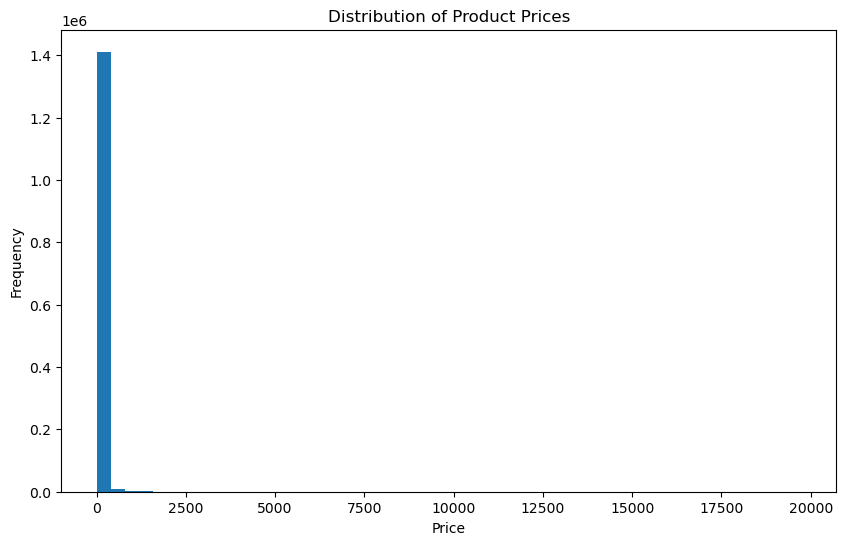

In [118]:
# PRICE DISTRIBUTION
plt.hist(df["price"], bins=50)

plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

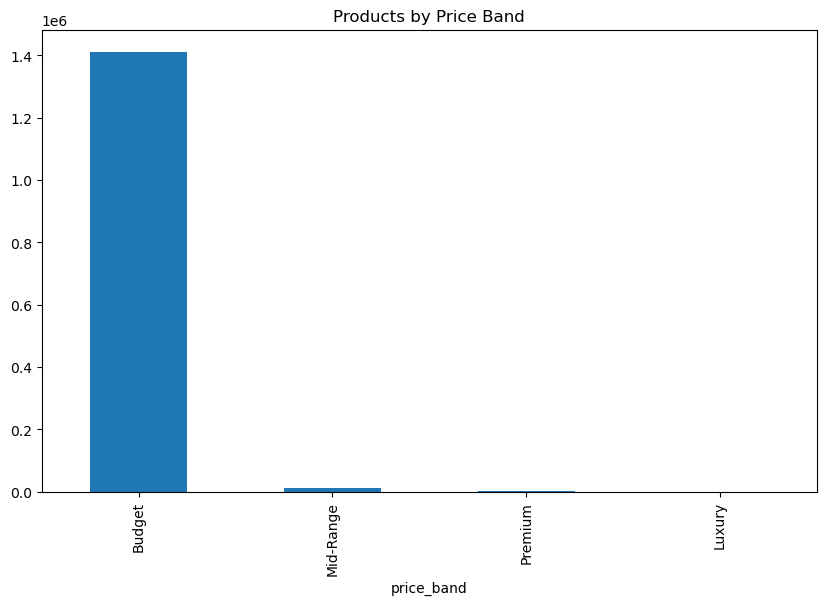

In [78]:
# PRICE BAND DISTRIBUTION
price_band = df["price_band"].value_counts()

price_band.plot(kind="bar")

plt.title("Products by Price Band")

plt.show()

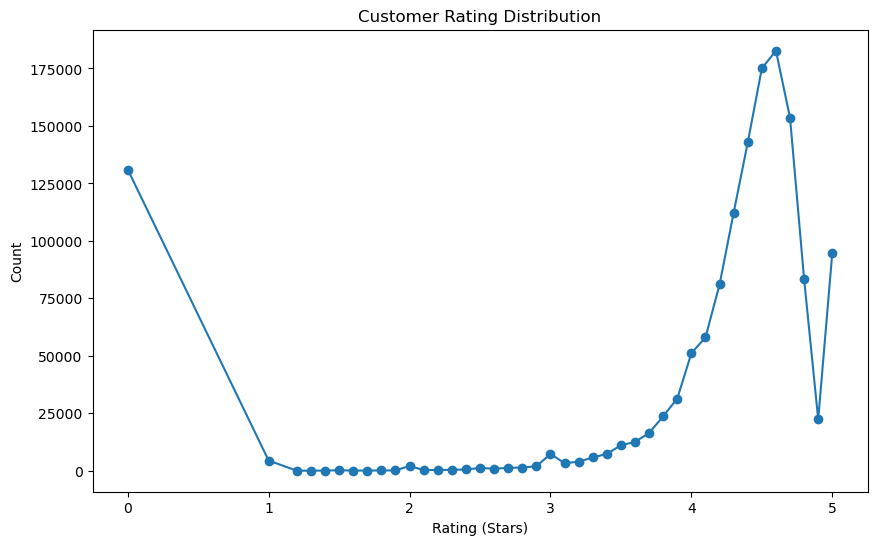

In [81]:
# RATING DISTRIBUTION
# 1. Count how many times each rating occurs, and sort by the rating value
rating_counts = df["stars"].value_counts().sort_index()

# 2. Plot it as a line graph
plt.plot(rating_counts.index, rating_counts.values, marker='o', linestyle='-')

# 3. Add labels and show
plt.title("Customer Rating Distribution")
plt.xlabel("Rating (Stars)")
plt.ylabel("Count")
plt.show()


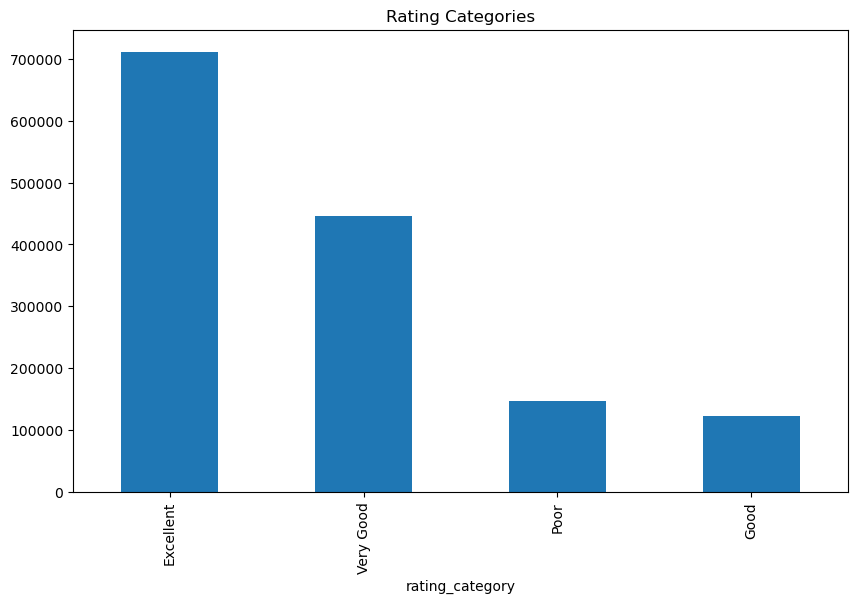

In [90]:
# RATING CATEGORY
df["rating_category"].value_counts().plot(kind="bar")

plt.title("Rating Categories")

plt.show()

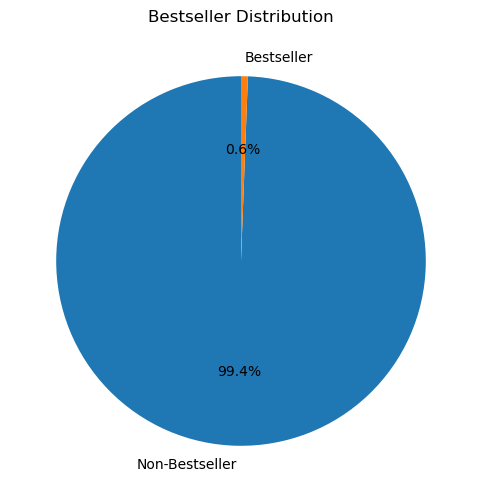

In [99]:
# BEST SELLER DISTRIBUTION
# 1. Plot the value counts as a pie chart
df["bestseller_label"].value_counts().plot(kind="pie", autopct='%1.1f%%', startangle=90)

# 2. Add title and clean layout
plt.title("Bestseller Distribution")
plt.ylabel("")  # Removes the overlapping vertical 'bestseller_label' text
plt.show()


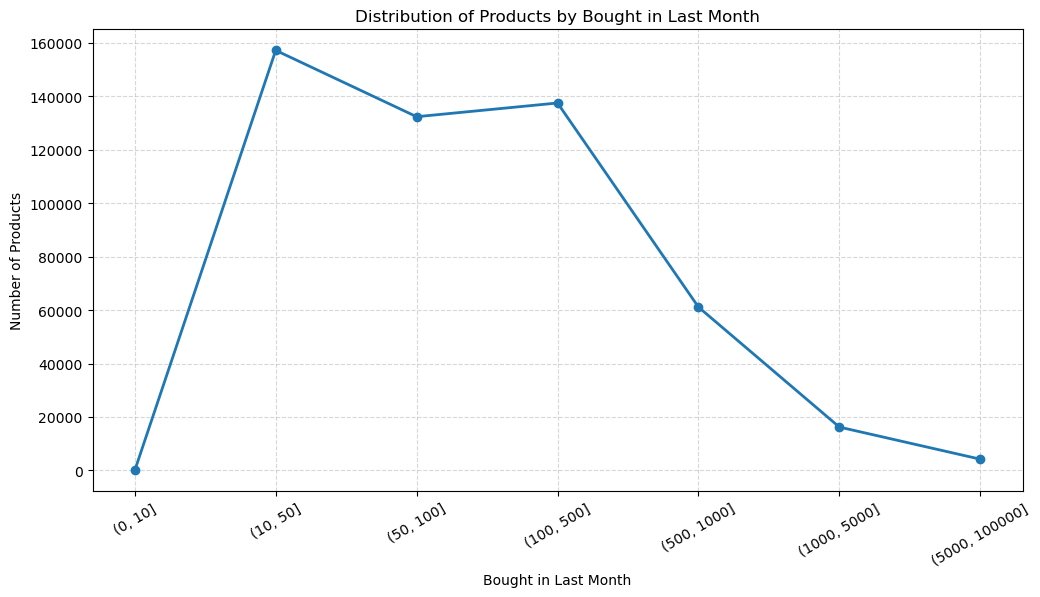

In [106]:
# BOUGHT IN LAST MONTHS
# Create bins
demand_bins = [0, 10, 50, 100, 500, 1000, 5000, df["boughtinlastmonth"].max()]

demand = (
    pd.cut(df["boughtinlastmonth"], bins=demand_bins)
      .value_counts()
      .sort_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    demand.index.astype(str),
    demand.values,
    marker='o',
    linewidth=2
)

plt.title("Distribution of Products by Bought in Last Month")
plt.xlabel("Bought in Last Month")
plt.ylabel("Number of Products")
plt.xticks(rotation=30)

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

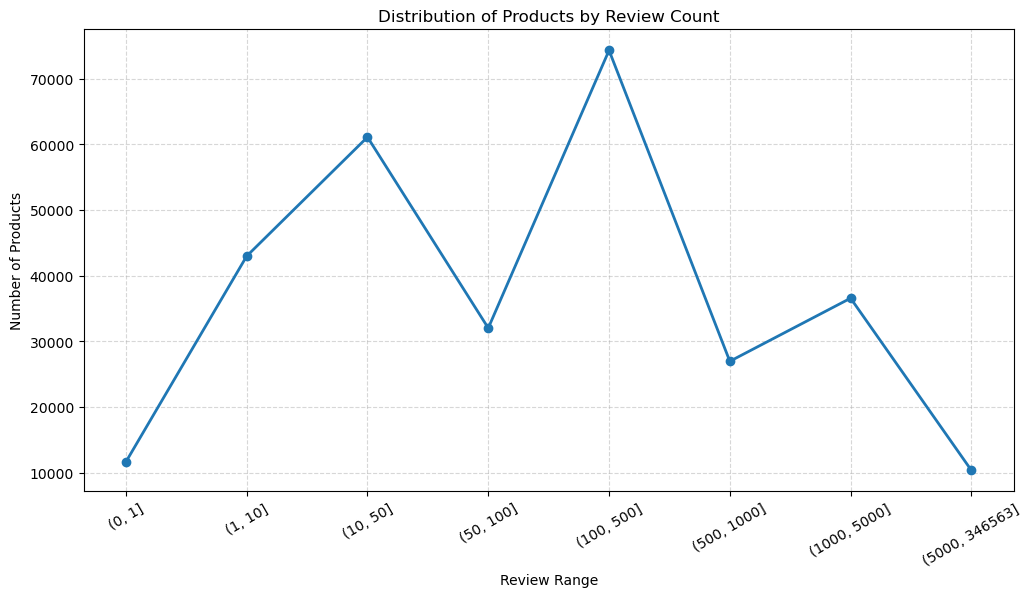

In [119]:
# REVIEWS GRAPH 
review_bins = [0, 1, 10, 50, 100, 500, 1000, 5000, df["reviews"].max()]

review_dist = (
    pd.cut(df["reviews"], bins=review_bins)
      .value_counts()
      .sort_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    review_dist.index.astype(str),
    review_dist.values,
    marker='o',
    linewidth=2
)

plt.title("Distribution of Products by Review Count")
plt.xlabel("Review Range")
plt.ylabel("Number of Products")
plt.xticks(rotation=30)

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### BIVARIATE ANALYSIS

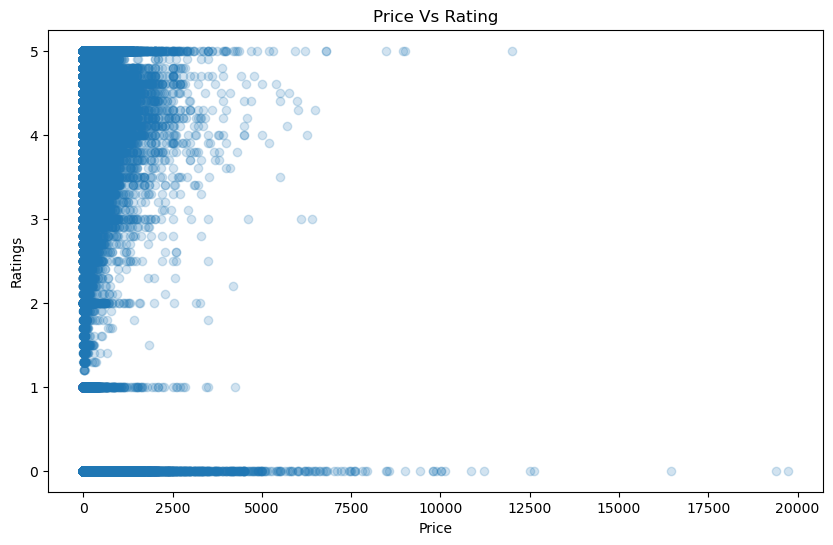

In [137]:
# PRICE VS RATING
plt.scatter(
    df["price"],
    df["stars"],
    alpha=0.2
)
plt.title("Price Vs Rating")
plt.xlabel("Price")
plt.ylabel("Ratings")

plt.show()

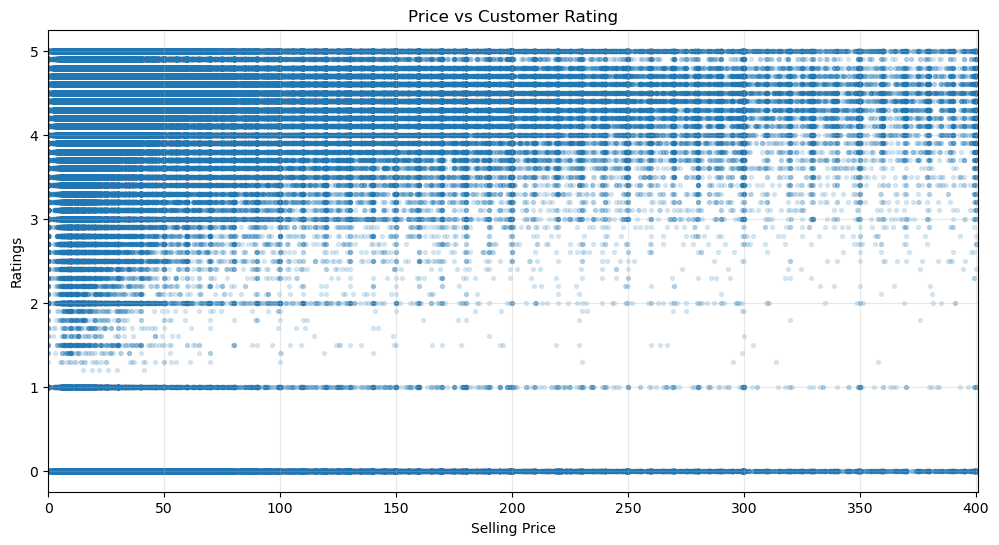

In [136]:
# IN DEPTH PRICE VS RATING
plt.figure(figsize=(12,6))

plt.scatter(
    df["price"],
    df["stars"],
    alpha=0.15,
    s=8
)

plt.xlim(0, df["price"].quantile(0.99))

plt.title("Price vs Customer Rating")
plt.xlabel("Selling Price")
plt.ylabel("Ratings")

plt.grid(alpha=0.3)

plt.show()

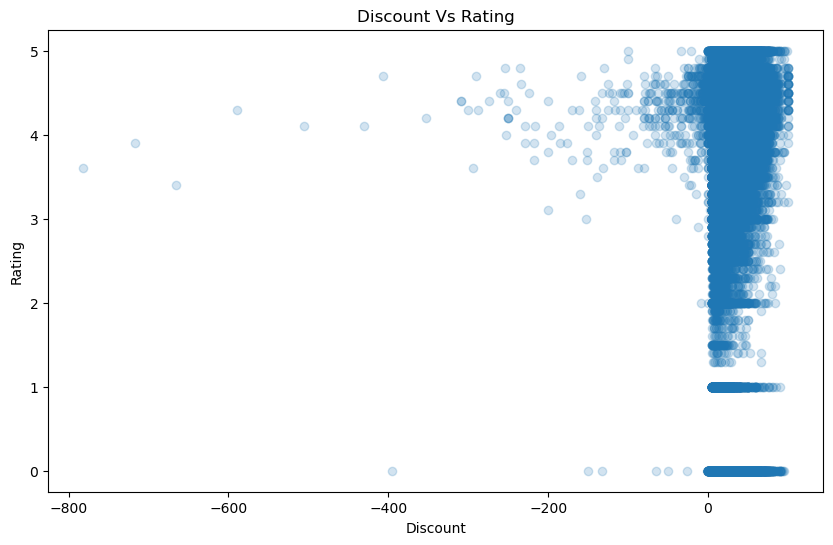

In [140]:
# DISCOUNT VS RATING
plt.scatter(
    df["discount_percentage"],
    df["stars"],
    alpha=0.2
)
plt.title("Discount Vs Rating")
plt.ylabel("Rating")
plt.xlabel("Discount")
plt.show()

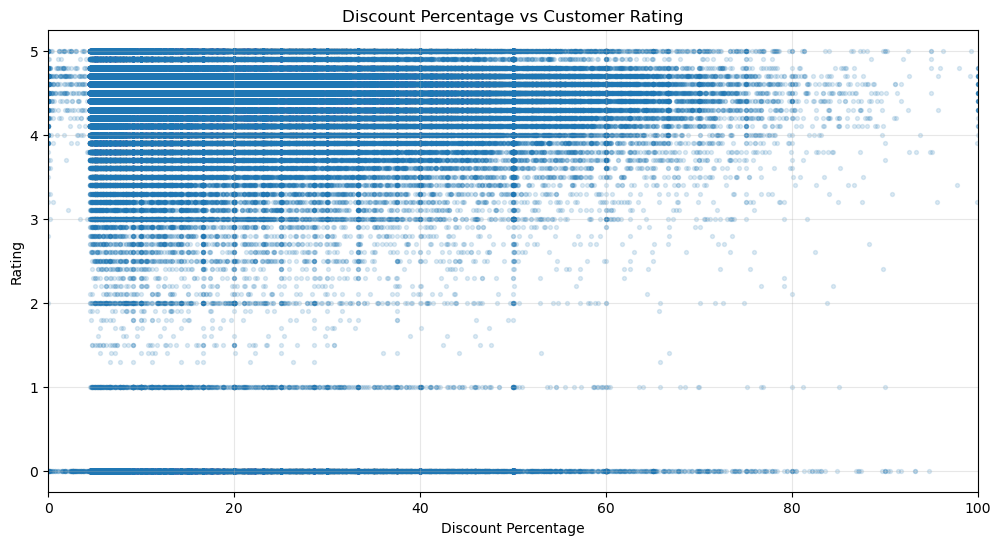

In [146]:
# IN DEPTH DISCOUNT VS RATING
plt.figure(figsize=(12,6))

plt.scatter(
    df["discount_percentage"],
    df["stars"],
    alpha=0.15,
    s=8
)

plt.xlim(0,100)

plt.title("Discount Percentage vs Customer Rating")
plt.xlabel("Discount Percentage")
plt.ylabel("Rating")

plt.grid(alpha=0.3)

plt.show()

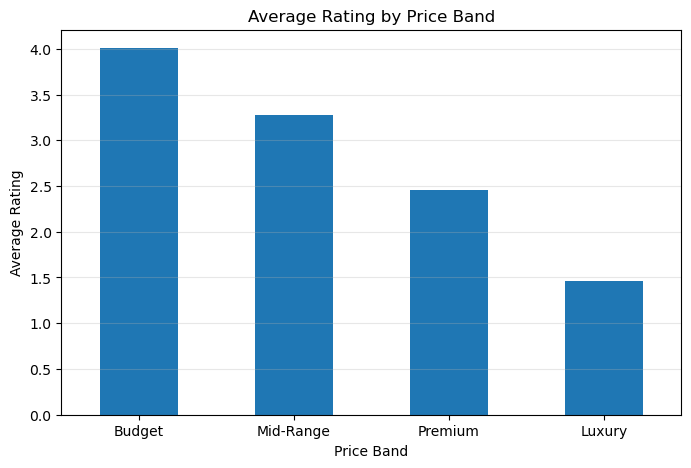

In [143]:
# Average Rating Across Price Bands (Bar Chart)
price_rating = (
    df.groupby("price_band")["stars"]
      .mean()
      .reindex(["Budget","Mid-Range","Premium","Luxury"])
)

plt.figure(figsize=(8,5))

price_rating.plot(kind="bar")

plt.title("Average Rating by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Average Rating")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.show()

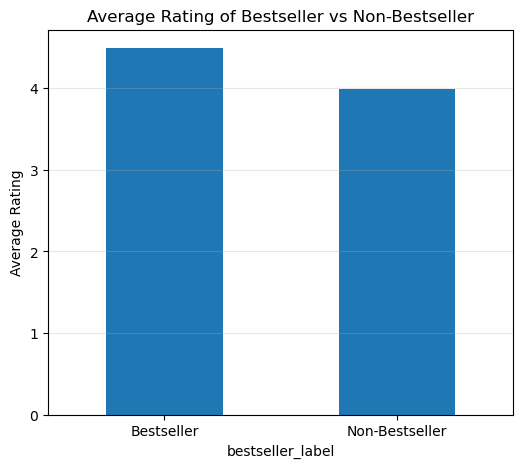

In [149]:
# BEST SELLER LABELLING
bestseller_rating = (
    df.groupby("bestseller_label")["stars"]
      .mean()
)

plt.figure(figsize=(6,5))

bestseller_rating.plot(kind="bar")

plt.title("Average Rating of Bestseller vs Non-Bestseller")
plt.ylabel("Average Rating")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.show()

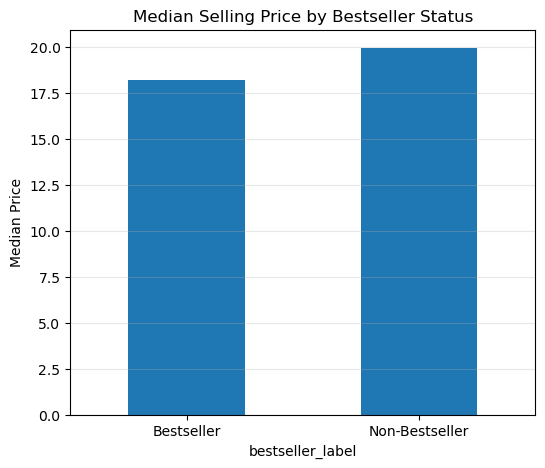

In [152]:
# BEST-SELLER VS PRICE
bestseller_price = (
    df.groupby("bestseller_label")["price"]
      .median()
)

plt.figure(figsize=(6,5))

bestseller_price.plot(kind="bar")

plt.title("Median Selling Price by Bestseller Status")
plt.ylabel("Median Price")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.show()

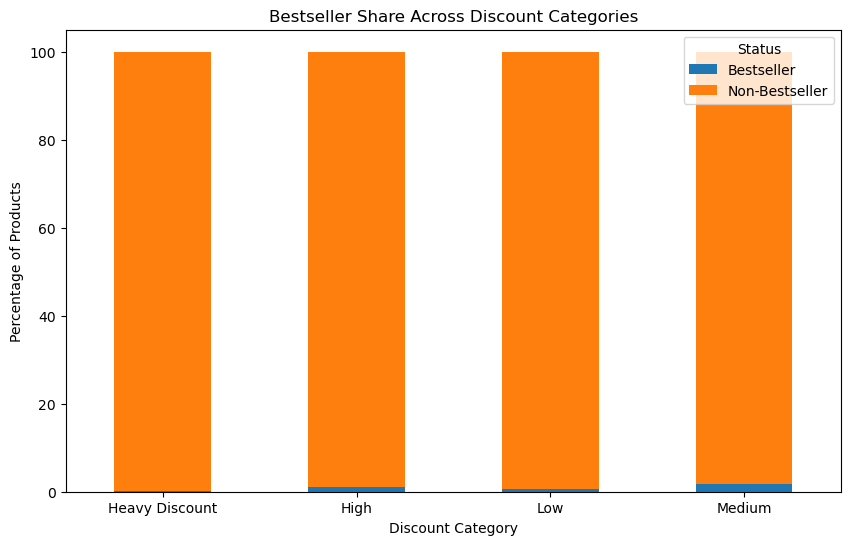

In [156]:
# DISCOUNT CATEGORY VS BEST-SELLER
discount_best = (
    pd.crosstab(
        df["discount_category"],
        df["bestseller_label"],
        normalize="index"
    ) * 100
)

discount_best.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Bestseller Share Across Discount Categories")
plt.xlabel("Discount Category")
plt.ylabel("Percentage of Products")

plt.xticks(rotation=0)

plt.legend(title="Status")

plt.show()

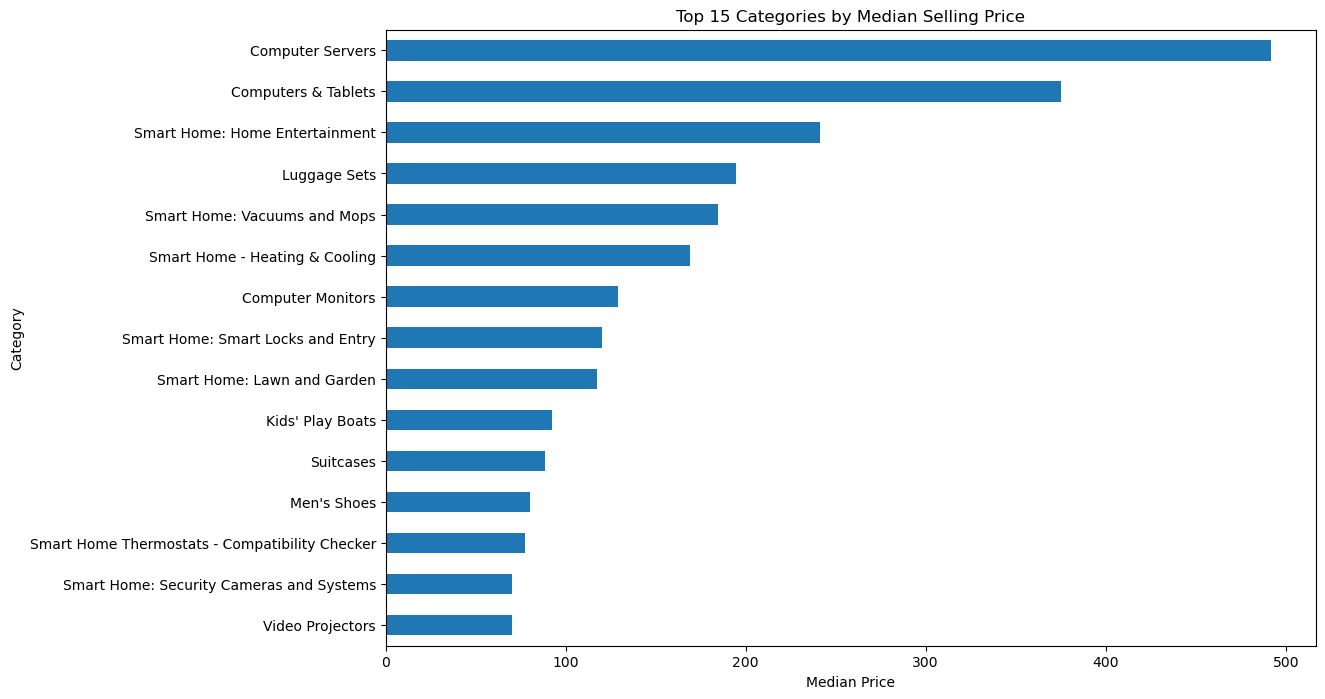

In [159]:
# TOP 15 CATEGORIES BY AVG PRICE
category_price = (
    df.groupby("amazon_category")["price"]
      .median()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12,8))

category_price.sort_values().plot(kind="barh")

plt.title("Top 15 Categories by Median Selling Price")
plt.xlabel("Median Price")
plt.ylabel("Category")

plt.show()

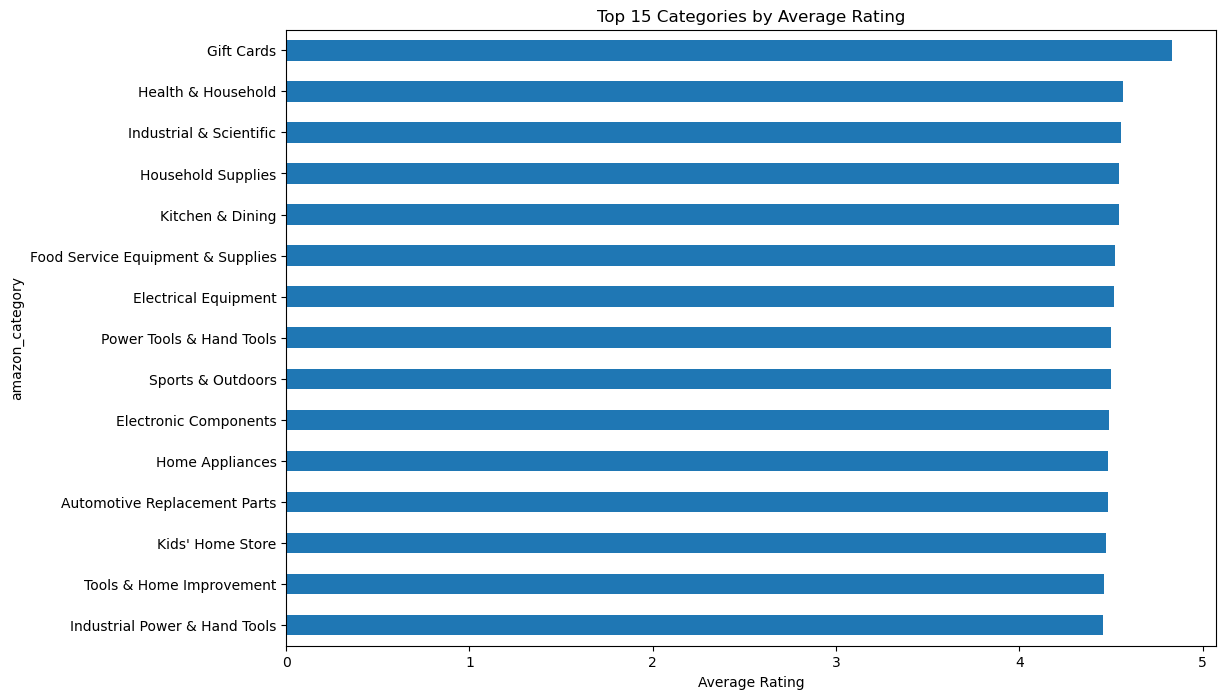

In [161]:
# TOP 15 CATEGORIES BY AVG RATING
category_rating = (
    df.groupby("amazon_category")["stars"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12,8))

category_rating.sort_values().plot(kind="barh")

plt.title("Top 15 Categories by Average Rating")
plt.xlabel("Average Rating")

plt.show()

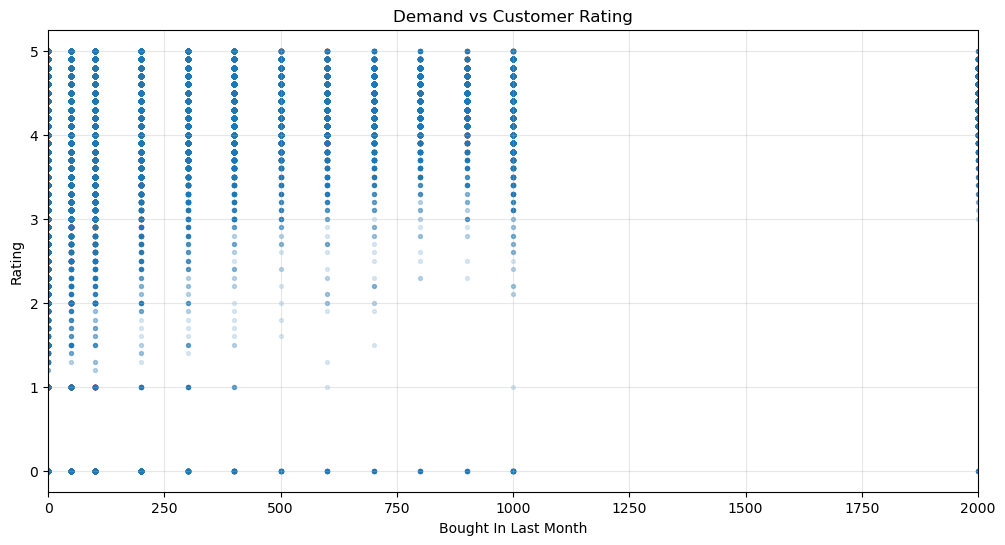

In [165]:
# DEMAND VS RATING
plt.figure(figsize=(12,6))

plt.scatter(
    df["boughtinlastmonth"],
    df["stars"],
    alpha=0.15,
    s=8
)

plt.xlim(0, df["boughtinlastmonth"].quantile(0.99))

plt.title("Demand vs Customer Rating")
plt.xlabel("Bought In Last Month")
plt.ylabel("Rating")

plt.grid(alpha=0.3)

plt.show()

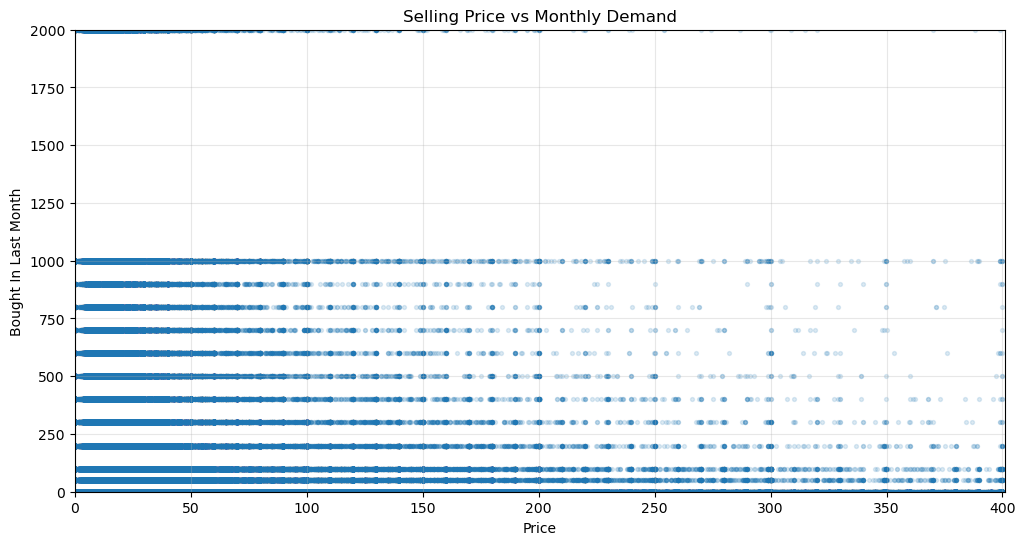

In [169]:
# PRICE VS DEMAND
plt.figure(figsize=(12,6))

plt.scatter(
    df["price"],
    df["boughtinlastmonth"],
    alpha=0.15,
    s=8
)

plt.xlim(0, df["price"].quantile(0.99))
plt.ylim(0, df["boughtinlastmonth"].quantile(0.99))

plt.title("Selling Price vs Monthly Demand")
plt.xlabel("Price")
plt.ylabel("Bought In Last Month")

plt.grid(alpha=0.3)

plt.show()

Key Insights

(Update these after running your final notebook. Replace any placeholders with your actual findings.)

Insight 1 — Product Pricing

The majority of products are concentrated in the Budget and Mid-Range price segments, indicating that Amazon's marketplace primarily caters to value-conscious customers.

Insight 2 — Customer Ratings

Most products receive ratings above 4.0 stars, suggesting generally positive customer satisfaction across the marketplace.

Insight 3 — Discounts

A significant proportion of products offer discounts, indicating that promotional pricing is a common marketplace strategy.

Insight 4 — Bestseller Distribution

Only a relatively small proportion of products achieve Bestseller status, suggesting that marketplace success is concentrated among a limited set of products.

Insight 5 — Reviews

The reviews variable is highly right-skewed. While a large percentage of products have zero reviews, a small number accumulate exceptionally high review counts. This long-tail distribution is typical in e-commerce marketplaces, where only a fraction of products generate substantial customer engagement.

Insight 6 — Pricing vs Customer Satisfaction

The relationship between product price and customer ratings appears weak, suggesting that higher prices do not necessarily translate into higher customer satisfaction.

Insight 7 — Product Demand

Most products experience relatively low monthly demand, while only a small subset attracts exceptionally high purchase volumes, indicating an uneven distribution of customer demand.

Insight 8 — Category Performance

Certain product categories consistently achieve higher average ratings and stronger pricing positions, highlighting potential opportunities for premium product strategies and focused marketing investments.